LIBRARIES AND CONFIGURATIONS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression



LOAD DATASET

In [2]:
df = pd.read_csv("../data/global_disaster_response_2018_2024 (1).csv")

PREPROCESSING

In [3]:
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["dayofyear"] = df["date"].dt.dayofyear
    df = df.drop(columns=["date"])

#Encoding categorical columns: 'country' and 'disaster_type'
le_country = LabelEncoder()
le_disaster = LabelEncoder()

df["country"] = le_country.fit_transform(df["country"])
df["disaster_type"] = le_disaster.fit_transform(df["disaster_type"])


Feature Selection and Train/Test Split

In [4]:
X = df.drop("recovery_days", axis=1)
y = df["recovery_days"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model Training

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0. , 0. , 0.02,..., 0. , 0. , 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['country','disaster_type','severity_index',...,'year','month','dayofyear']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.445
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [7]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
pred[:10]   

array([ 85.65,  74.98,  50.91,  22.56,  39.74,  30.49,  50.94, 100.57,
        68.26,  43.91])

Model Evaluation

In [8]:
mse = mean_squared_error(y_test, pred)
rmse = (mse) ** 0.5
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)


RMSE: 5.115812603096404
MAE: 4.074318999999999
R²: 0.9355358224099789


Feature Importance(Random Forest)

In [9]:
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance_df)

                      feature  importance
2              severity_index    0.941966
9                   longitude    0.006410
6              aid_amount_usd    0.006290
8                    latitude    0.006226
4           economic_loss_usd    0.006212
3                  casualties    0.005766
5         response_time_hours    0.005654
7   response_efficiency_score    0.005528
12                  dayofyear    0.005234
0                     country    0.003987
1               disaster_type    0.003017
10                       year    0.002470
11                      month    0.001240


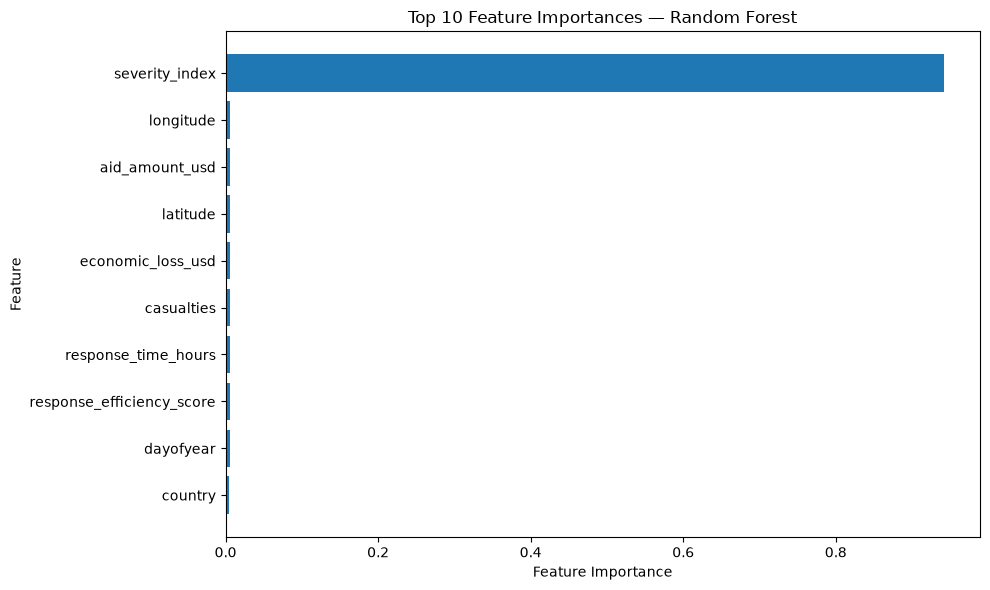

In [18]:
plt.figure(figsize=(10, 6))

top_features = feature_importance_df.head(10)

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Exploratory Data Analysis (EDA)  
1.Top 10 Countries by Disaster Count

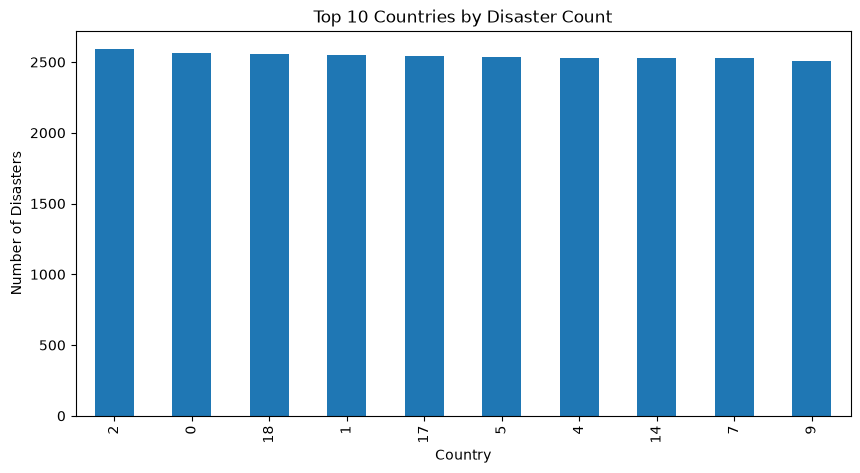

In [11]:
plt.figure(figsize=(10,5))
df["country"].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries by Disaster Count")
plt.xlabel("Country")
plt.ylabel("Number of Disasters")
plt.show()


Exploratory Data Analysis (EDA)
2.Distribution of Disaster Types

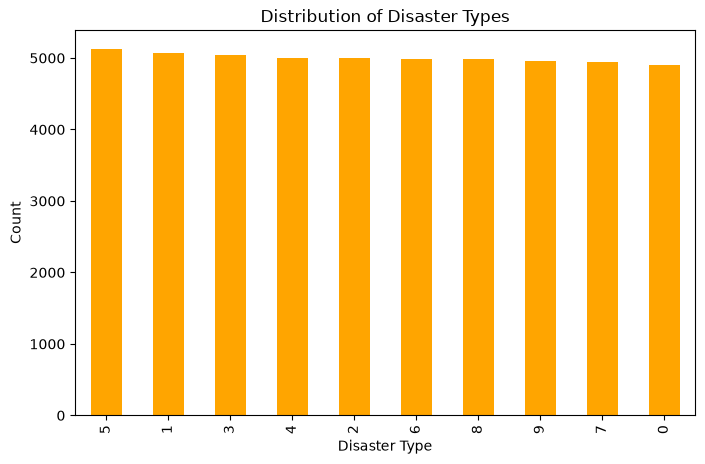

In [12]:
plt.figure(figsize=(8,5))
df["disaster_type"].value_counts().plot(kind='bar', color='orange')
plt.title("Distribution of Disaster Types")
plt.xlabel("Disaster Type")
plt.ylabel("Count")
plt.show()


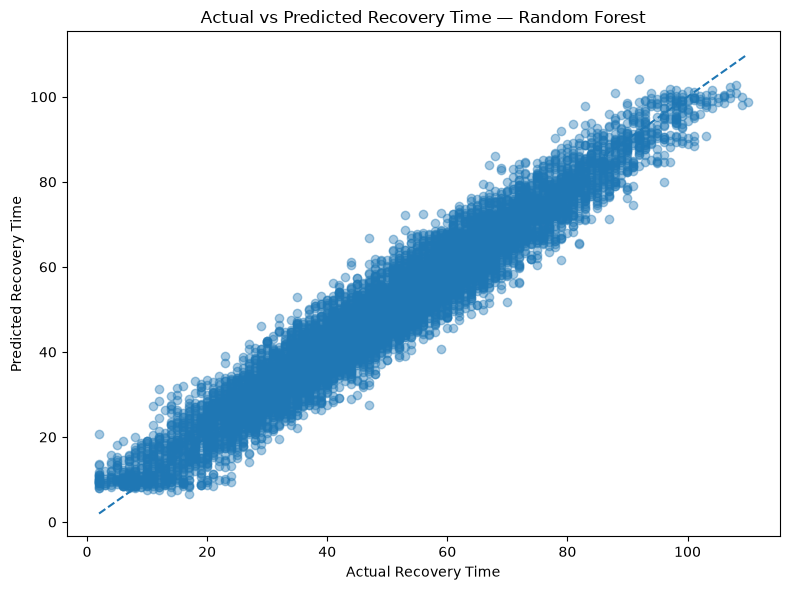

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, pred, alpha=0.4)

min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Recovery Time")
plt.ylabel("Predicted Recovery Time")
plt.title("Actual vs Predicted Recovery Time — Random Forest")
plt.tight_layout()
plt.savefig(
    "../images/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Exploratory Data Analysis (EDA)
3.Recovery Days by Disaster Type (Boxplot)

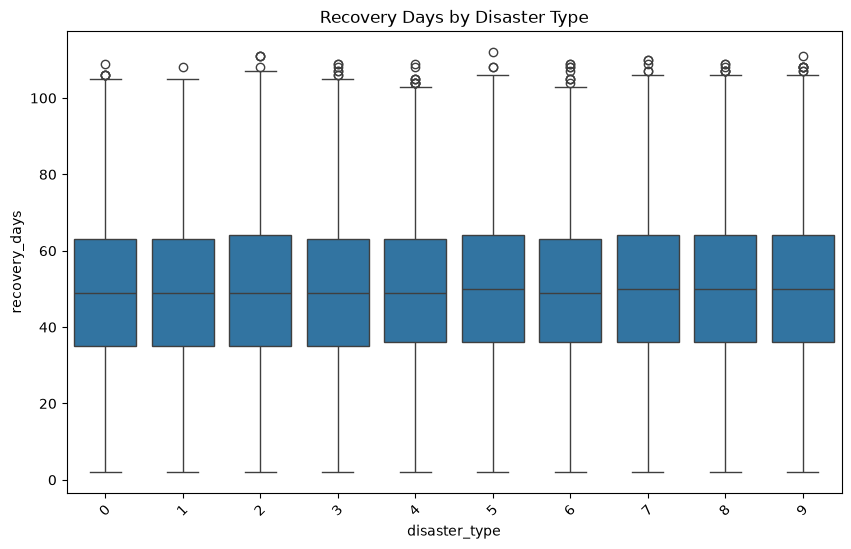

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df["disaster_type"], y=df["recovery_days"])
plt.xticks(rotation=45)
plt.title("Recovery Days by Disaster Type")
plt.show()


Exploratory Data Analysis (EDA)
4.Severity vs Recovery Days (Scatter Plot)

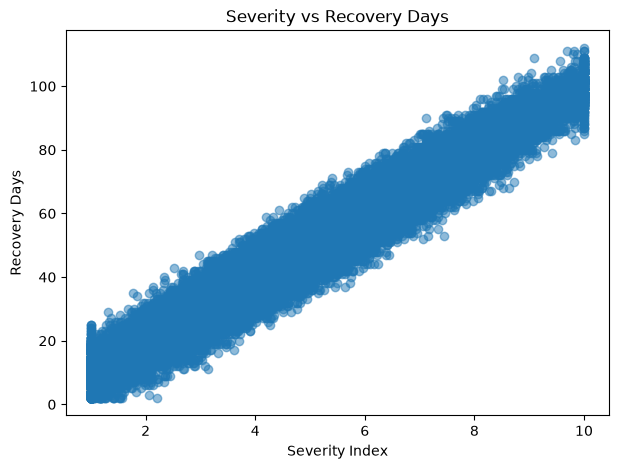

In [15]:
plt.figure(figsize=(7,5))
plt.scatter(df["severity_index"], df["recovery_days"], alpha=0.5)
plt.xlabel("Severity Index")
plt.ylabel("Recovery Days")
plt.title("Severity vs Recovery Days")
plt.show()
